In [1]:
# ============================================================
# CELL 1 — Install required libraries
# ============================================================
!pip install rasterio geopandas matplotlib scikit-learn numpy -q

In [2]:
import os
BASE_DIR = "/kaggle/input/datasets/saharfeki/dataset-uae-class/UAE_Classification" 
BASE_DIR2 = "/kaggle/input/datasets/saharfeki/image1" 
BASE_DIR3 = "/kaggle/input/datasets/saharfeki/desert-data/3"
BASE_DIR7 = "/kaggle/input/datasets/saharfeki/image5"
BASE_DIR8 = "/kaggle/input/datasets/saharfeki/water-class4"

IMAGE_PATH = f"{BASE_DIR7}/uae_feature_stack-0000010496-0000031488.tif"

SHP_BUILDINGS  = f"{BASE_DIR}/shapefiles/gis_osm_buildings.shp"
SHP_VEGETATION = f"{BASE_DIR}/shapefiles/landuse_veg_class2.shp"
SHP_VEGETATION = f"{BASE_DIR}/shapefiles/natural_veg_class2.shp"
SHP_WATER      = f"{BASE_DIR8}/water.shp"
SHP_DESERT     =f"{BASE_DIR3}/desert.shp"

# Outputs go here (Kaggle working directory — you can download from here)
OUTPUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ Paths set")
print(f"   Output folder: {OUTPUT_DIR}")

✅ Paths set
   Output folder: /kaggle/working/outputs


In [3]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.plot import show
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import os
import warnings
warnings.filterwarnings("ignore")

In [4]:
with rasterio.open(IMAGE_PATH) as src:
    image        = src.read().astype(np.float32)  # (10, H, W)
    raster_crs   = src.crs
    raster_transform = src.transform
    raster_bounds    = src.bounds
    raster_shape     = (src.height, src.width)
    raster_profile   = src.profile

print(f"Image shape   : {image.shape}  → (bands, height, width)")
print(f"CRS           : {raster_crs}")
print(f"Bounds        : {raster_bounds}")
print(f"Resolution    : {src.res} meters")
print(f"Pixel count   : {raster_shape[0] * raster_shape[1]:,}")

Image shape   : (10, 10496, 10496)  → (bands, height, width)
CRS           : EPSG:4326
Bounds        : BoundingBox(left=54.358315483470015, bottom=24.183635595310047, right=55.30118720568186, top=25.1265073175219)
Resolution    : (8.983152841195215e-05, 8.983152841195215e-05) meters
Pixel count   : 110,166,016


In [5]:
from shapely.geometry import box

def load_and_clip(shp_path, crs, bounds, class_id):
    """Load shapefile, reproject, clip to tile extent, add class_id"""
    gdf = gpd.read_file(shp_path)
    print(f"  Loaded {os.path.basename(shp_path)}: {len(gdf)} features, CRS={gdf.crs}")

    # Reproject to raster CRS
    if gdf.crs != crs:
        gdf = gdf.to_crs(crs)

    # Clip to tile bounding box
    tile_bbox = box(*bounds)
    gdf = gdf[gdf.intersects(tile_bbox)].copy()
    gdf = gdf.clip(tile_bbox)

    # Assign class_id (override if column exists)
    gdf["class_id"] = class_id

    # Drop empty geometries
    gdf = gdf[~gdf.geometry.is_empty & gdf.geometry.notna()]

    print(f"  → After clip: {len(gdf)} features in tile extent")
    return gdf

print("Loading shapefiles...")
buildings  = load_and_clip(SHP_BUILDINGS,  raster_crs, raster_bounds, class_id=1)
vegetation = load_and_clip(SHP_VEGETATION, raster_crs, raster_bounds, class_id=2)
water      = load_and_clip(SHP_WATER,      raster_crs, raster_bounds, class_id=4)
desert = load_and_clip(SHP_DESERT, raster_crs, raster_bounds, class_id=3)

print("\n✅ All shapefiles loaded and clipped")

Loading shapefiles...
  Loaded gis_osm_buildings.shp: 606221 features, CRS=EPSG:4326
  → After clip: 190898 features in tile extent
  Loaded natural_veg_class2.shp: 27496 features, CRS=EPSG:4326
  → After clip: 20131 features in tile extent
  Loaded water.shp: 10 features, CRS=EPSG:4326
  → After clip: 6 features in tile extent
  Loaded desert.shp: 26 features, CRS=EPSG:4326
  → After clip: 4 features in tile extent

✅ All shapefiles loaded and clipped


Rasterizing...
  Class 3: 499,543 labeled pixels
  Class 2: 15,063 labeled pixels
  Class 4: 92,653 labeled pixels
  Class 1: 1,080,777 labeled pixels

Label summary:
  Class 1 Urban      :  1,080,777 pixels
  Class 2 Vegetation :     14,689 pixels
  Class 3 Desert     :    499,543 pixels
  Class 4 Water      :     92,653 pixels
  Unlabeled (0)      : 108,478,354 pixels
  Total labeled      :  1,687,662 / 110,166,016 (1.5%)


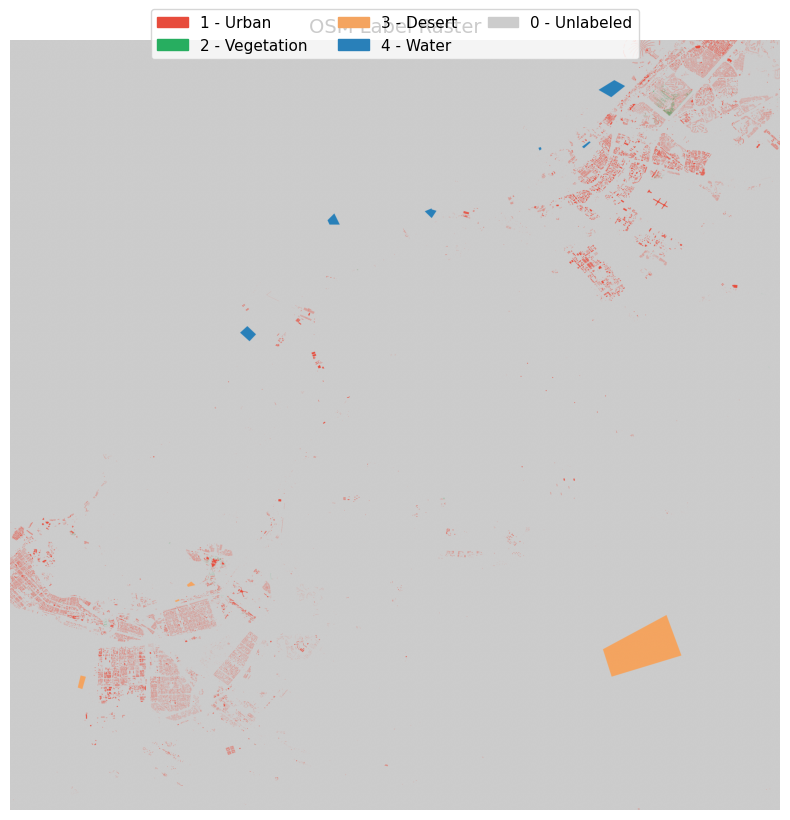

✅ Rasterization done


In [6]:
def rasterize_layer(gdf, class_id, shape, transform):
    """Burn a GeoDataFrame into a raster with given class_id"""
    if gdf.empty:
        print(f"  ⚠️  Class {class_id}: empty GeoDataFrame, skipping")
        return np.zeros(shape, dtype=np.uint8)

    shapes = [
        (geom, class_id)
        for geom in gdf.geometry
        if geom is not None and not geom.is_empty
    ]

    burned = rasterize(
        shapes,
        out_shape=shape,
        transform=transform,
        fill=0,
        dtype=np.uint8
    )
    print(f"  Class {class_id}: {np.sum(burned == class_id):,} labeled pixels")
    return burned

# Start with empty label raster
label_raster = np.zeros(raster_shape, dtype=np.uint8)

# Burn in priority order: desert first, then vegetation, then water, then buildings (highest priority)
print("Rasterizing...")
for gdf, cid in [(desert, 3), (vegetation, 2), (water, 4), (buildings, 1)]:
    burned = rasterize_layer(gdf, cid, raster_shape, raster_transform)
    label_raster = np.where(burned > 0, burned, label_raster)

total_labeled = np.sum(label_raster > 0)
total_pixels  = raster_shape[0] * raster_shape[1]

print(f"\nLabel summary:")
print(f"  Class 1 Urban      : {np.sum(label_raster==1):>10,} pixels")
print(f"  Class 2 Vegetation : {np.sum(label_raster==2):>10,} pixels")
print(f"  Class 3 Desert     : {np.sum(label_raster==3):>10,} pixels")
print(f"  Class 4 Water      : {np.sum(label_raster==4):>10,} pixels")
print(f"  Unlabeled (0)      : {np.sum(label_raster==0):>10,} pixels")
print(f"  Total labeled      : {total_labeled:>10,} / {total_pixels:,} ({100*total_labeled/total_pixels:.1f}%)")

# Visualize label raster with desert (class 3) included
# Color mapping: Unlabeled (0)=gray, Urban (1)=red, Vegetation (2)=green, 
# Desert (3)=tan/sand color, Water (4)=blue
cmap_label = mcolors.ListedColormap(["#cccccc", "#e74c3c", "#27ae60", "#f4a460", "#2980b9"])
fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(label_raster, cmap=cmap_label, vmin=0, vmax=4)

# Legend with desert included, placed at top (either 'upper right', 'upper left', or 'upper center')
legend = [
    mpatches.Patch(color="#e74c3c", label="1 - Urban"),
    mpatches.Patch(color="#27ae60", label="2 - Vegetation"),
    mpatches.Patch(color="#f4a460", label="3 - Desert"),
    mpatches.Patch(color="#2980b9", label="4 - Water"),
    mpatches.Patch(color="#cccccc", label="0 - Unlabeled"),
]
ax.legend(handles=legend, loc="upper center", fontsize=11, bbox_to_anchor=(0.5, 1.05), ncol=3)
ax.set_title("OSM Label Raster", fontsize=14)
ax.axis("off")
plt.savefig(f"{OUTPUT_DIR}/02_label_raster.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Rasterization done")

In [7]:
# ============================================================
# CELL 7 — Extract pixel samples for training
# ============================================================

# Flatten image: (10, H, W) → (N_pixels, 10)
H, W = raster_shape
X_all = image.reshape(10, -1).T       # all pixels, all bands
y_all = label_raster.reshape(-1)      # all labels

# Keep only labeled pixels
labeled_mask = y_all > 0
X = X_all[labeled_mask]
y = y_all[labeled_mask]

print(f"Total pixels    : {X_all.shape[0]:,}")
print(f"Labeled pixels  : {X.shape[0]:,}")
print(f"\nClass distribution:")
# Update to include desert (class 3)
for cid, cname in [(1,"Urban"), (2,"Vegetation"), (3,"Desert"), (4,"Water")]:
    count = np.sum(y == cid)
    pct   = 100 * count / len(y)
    print(f"  Class {cid} {cname:<12}: {count:>8,}  ({pct:.1f}%)")

# ⚠️ Check for severe imbalance (update to include class 3)
min_class = min(np.sum(y==c) for c in [1,2,3,4])
if min_class < 500:
    print(f"\n⚠️  Warning: smallest class has only {min_class} samples.")
    print("   Consider adding manual polygons in QGIS for that class.")
else:
    print("\n✅ Sample extraction done — class sizes look reasonable")

# Sample with balanced classes (including desert)
MAX_PER_CLASS = 200_000
X_list, y_list = [], []

# Updated loop to include class 3 (desert)
for cid in [1, 2, 3, 4]:    # ← desert (3) added
    idx = np.where(y == cid)[0]  # Note: changed y_labeled to y
    if len(idx) == 0:
        print(f"⚠️  Class {cid}: no samples found!")
        continue
    n = min(MAX_PER_CLASS, len(idx))
    sampled = np.random.choice(idx, size=n, replace=False)
    X_list.append(X[sampled])  # Note: changed X_labeled to X
    y_list.append(y[sampled])  # Note: changed y_labeled to y
    print(f"  Class {cid}: {n:,} samples selected (available: {len(idx):,})")

# Combine sampled data
if X_list:  # Check if any classes were sampled
    X_sampled = np.vstack(X_list)
    y_sampled = np.hstack(y_list)
    print(f"\n✅ Total samples selected: {len(y_sampled):,}")
else:
    print("\n❌ No samples were selected! Check your label raster.")

Total pixels    : 110,166,016
Labeled pixels  : 1,687,662

Class distribution:
  Class 1 Urban       : 1,080,777  (64.0%)
  Class 2 Vegetation  :   14,689  (0.9%)
  Class 3 Desert      :  499,543  (29.6%)
  Class 4 Water       :   92,653  (5.5%)

✅ Sample extraction done — class sizes look reasonable
  Class 1: 200,000 samples selected (available: 1,080,777)
  Class 2: 14,689 samples selected (available: 14,689)
  Class 3: 200,000 samples selected (available: 499,543)
  Class 4: 92,653 samples selected (available: 92,653)

✅ Total samples selected: 507,342


Training samples : 1,350,129
Test samples     : 337,533

Training Random Forest...
✅ Training done

── Classification Report ──────────────────────────────
              precision    recall  f1-score   support

       Urban       1.00      0.95      0.97    216156
  Vegetation       0.23      0.78      0.36      2938
      Desert       1.00      1.00      1.00     99909
       Water       0.82      1.00      0.90     18530

    accuracy                           0.96    337533
   macro avg       0.76      0.93      0.81    337533
weighted avg       0.98      0.96      0.97    337533



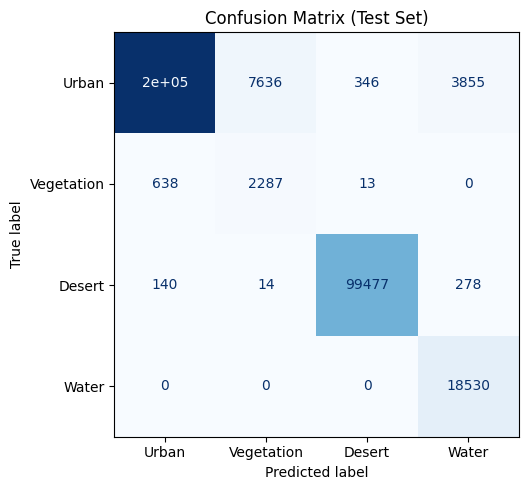


── Per-class Accuracy ────────────────────────────────
  Urban       : 94.5% (204,319/216,156)
  Vegetation  : 77.8% (2,287/2,938)
  Desert      : 99.6% (99,477/99,909)
  Water       : 100.0% (18,530/18,530)


In [8]:
# ============================================================
# CELL 8 — Train/test split and Random Forest
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # keeps class proportions in both splits
)

print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    class_weight="balanced",   # handles imbalanced classes
    n_jobs=-1,
    random_state=42
)

print("\nTraining Random Forest...")
rf.fit(X_train, y_train)
print("✅ Training done")

# Evaluate
y_pred = rf.predict(X_test)

# Update classification report to include class 3 (Desert)
print("\n── Classification Report ──────────────────────────────")
print(classification_report(
    y_test, y_pred,
    labels=[1, 2, 3, 4],                                    # ← includes class 3
    target_names=["Urban", "Vegetation", "Desert", "Water"]   # ← Desert added
))

# Update confusion matrix to include class 3 (Desert)
cm = confusion_matrix(y_test, y_pred, labels=[1, 2, 3, 4])
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(
    cm,
    display_labels=["Urban", "Vegetation", "Desert", "Water"]   # ← Desert added
)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_confusion_matrix.png", dpi=150)
plt.show()

# Optional: Print per-class accuracy
print("\n── Per-class Accuracy ────────────────────────────────")
for i, label in enumerate(["Urban", "Vegetation", "Desert", "Water"]):
    correct = np.sum((y_pred == y_test) & (y_test == [1,2,3,4][i]))
    total = np.sum(y_test == [1,2,3,4][i])
    if total > 0:
        acc = 100 * correct / total
        print(f"  {label:12}: {acc:.1f}% ({correct:,}/{total:,})")
    else:
        print(f"  {label:12}: No samples in test set")

Band importance ranking:
   1. B11      0.1810  ██████████████████
   2. NDVI     0.1707  █████████████████
   3. GHSL     0.1504  ███████████████
   4. B4       0.1163  ███████████
   5. B8       0.1017  ██████████
   6. BSI      0.0731  ███████
   7. B2       0.0720  ███████
   8. B3       0.0668  ██████
   9. MNDWI    0.0340  ███
  10. NDBI     0.0338  ███


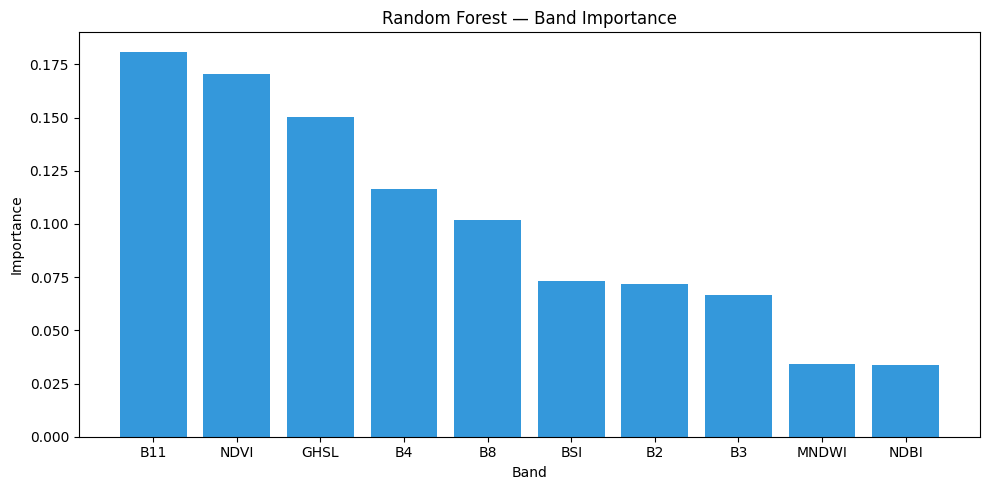

In [9]:
# ============================================================
# CELL 9 — Band importance
# ============================================================


BAND_NAMES = ["B2","B3","B4","B8","B11","NDVI","NDBI","MNDWI","BSI","GHSL"]

importances = rf.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

print("Band importance ranking:")
for rank, i in enumerate(sorted_idx):
    bar = "█" * int(importances[i] * 100)
    print(f"  {rank+1:2}. {BAND_NAMES[i]:<8} {importances[i]:.4f}  {bar}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    [BAND_NAMES[i] for i in sorted_idx],
    [importances[i] for i in sorted_idx],
    color="#3498db"
)
ax.set_title("Random Forest — Band Importance")
ax.set_ylabel("Importance")
ax.set_xlabel("Band")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_band_importance.png", dpi=150)
plt.show()

In [10]:
# ============================================================
# CELL 10 — Valid mask + Predict + Desert mask (NaN fix)
# ============================================================
import gc
import numpy as np
import rasterio

BAND_NAMES = ["B2","B3","B4","B8","B11","NDVI","NDBI","MNDWI","BSI","GHSL"]

# ── Step 1: Valid mask from NaN ──────────────────────────────
with rasterio.open(IMAGE_PATH) as src:
    b1 = src.read(1).astype(np.float32)

valid_mask      = ~np.isnan(b1)
valid_mask_flat = valid_mask.reshape(-1)

del b1
gc.collect()

print(f"Valid pixels  : {np.sum(valid_mask_flat):,}")
print(f"NaN pixels    : {np.sum(~valid_mask_flat):,}")

# ── Step 2: Predict valid pixels only ───────────────────────
print("\nPredicting valid pixels only...")

H, W = raster_shape
classified_flat = np.zeros(H * W, dtype=np.uint8)

with rasterio.open(IMAGE_PATH) as src:
    image_temp = src.read().astype(np.float32)

# Replace NaN with 0 before prediction
image_temp = np.nan_to_num(image_temp, nan=0.0)

X_valid = image_temp.reshape(image_temp.shape[0], -1).T[valid_mask_flat]

del image_temp
gc.collect()

classified_flat[valid_mask_flat] = rf.predict(X_valid).astype(np.uint8)

del X_valid
gc.collect()

classified_map = classified_flat.reshape(H, W)
del classified_flat
gc.collect()

# ── Step 3: Desert mask (reflectance scale thresholds) ──────
print("Applying desert mask...")

with rasterio.open(IMAGE_PATH) as src:
    ghsl = src.read(10).astype(np.float32)   # GHSL  — band 10
    bsi  = src.read(9).astype(np.float32)    # BSI   — band 9
    ndvi = src.read(6).astype(np.float32)    # NDVI  — band 6

# Replace NaN in index bands too
ghsl = np.nan_to_num(ghsl, nan=0.0)
bsi  = np.nan_to_num(bsi,  nan=0.0)
ndvi = np.nan_to_num(ndvi, nan=0.0)

# Reflectance-scale thresholds
GHSL_THRESHOLD = 10     # GHSL: 0–100 density
BSI_THRESHOLD  = 0.0    # BSI > 0 = bare soil
NDVI_THRESHOLD = 0.15   # NDVI < 0.15 = no vegetation

desert_mask = (
    (ghsl < GHSL_THRESHOLD)             &
    (bsi  > BSI_THRESHOLD)              &
    (ndvi < NDVI_THRESHOLD)             &
    valid_mask                          &   # only real pixels
    ~np.isin(classified_map, [1, 2, 4])     # don't override confident classes
)

classified_map[desert_mask] = 3

del ghsl, bsi, ndvi, desert_mask
gc.collect()

# ── Step 4: Mask NaN areas back to 0 ────────────────────────
classified_map[~valid_mask] = 0

del valid_mask, valid_mask_flat
gc.collect()

# ── Summary ─────────────────────────────────────────────────
total_valid = np.sum(classified_map > 0)
print(f"\nFinal class distribution:")
for cid, cname in [(1,"Urban"),(2,"Vegetation"),(3,"Desert"),(4,"Water")]:
    count = np.sum(classified_map == cid)
    pct   = 100 * count / total_valid if total_valid > 0 else 0
    print(f"  Class {cid} {cname:<12}: {count:>10,}  ({pct:.1f}% of valid pixels)")

print("\n✅ Prediction done")

Valid pixels  : 73,508,160
NaN pixels    : 36,657,856

Predicting valid pixels only...
Applying desert mask...

Final class distribution:
  Class 1 Urban       : 23,026,445  (31.3% of valid pixels)
  Class 2 Vegetation  :  3,199,386  (4.4% of valid pixels)
  Class 3 Desert      : 46,493,704  (63.2% of valid pixels)
  Class 4 Water       :    788,625  (1.1% of valid pixels)

✅ Prediction done


In [11]:
# ============================================================
# CELL 12 — 2018 version: Apply 2024 RF directly to 2018 imagery
# ============================================================
import gc
import numpy as np
import rasterio
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from rasterio.merge import merge

# ── 2018 image paths (must have same 10 bands: B2,B3,B4,B8,B11,NDVI,NDBI,MNDWI,BSI,GHSL) ──
BASE_DIR11 = "/kaggle/input/datasets/saharfeki/image-2018-1"
BASE_DIR12 = "/kaggle/input/datasets/saharfeki/image-2018-2"
BASE_DIR13 = "/kaggle/input/datasets/saharfeki/image3-2018"
BASE_DIR14 = "/kaggle/input/datasets/saharfeki/image4-2018"

IMAGE_PATHS = [
    f"{BASE_DIR11}/uae_feature_stack_tile2.tif",
    f"{BASE_DIR12}/uae_feature_stack_tile3.tif",
    f"{BASE_DIR13}/uae_feature_stack_tile4.tif",
    f"{BASE_DIR14}/uae_feature_stack_tile1.tif",
]

OUTPUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Same thresholds as 2024 ──
GHSL_THRESHOLD = 10
BSI_THRESHOLD  = 0.0
NDVI_THRESHOLD = 0.15

classified_paths = []

for tile_idx, img_path in enumerate(IMAGE_PATHS):
    tile_name = os.path.basename(img_path).replace(".tif", "")
    out_path  = f"{OUTPUT_DIR}/uae_classified_2018.tif"  # ← 2018 suffix

    print(f"\n{'='*55}")
    print(f"Processing 2018 tile {tile_idx+1}/{len(IMAGE_PATHS)} : {tile_name}")
    print(f"{'='*55}")

    # ── Step 1: Valid mask ───────────────────────────────────
    with rasterio.open(img_path) as src:
        # Verify band count matches RF expectation (10 bands)
        if src.count != 10:
            raise ValueError(f"Expected 10 bands, got {src.count}. RF was trained on 10 bands.")
        
        b1             = src.read(1).astype(np.float32)
        raster_shape   = (src.height, src.width)
        raster_profile = src.profile.copy()

    valid_mask      = ~np.isnan(b1)
    valid_mask_flat = valid_mask.reshape(-1)
    H, W            = raster_shape

    del b1
    gc.collect()

    print(f"  Valid pixels : {np.sum(valid_mask_flat):,}")
    print(f"  NaN pixels   : {np.sum(~valid_mask_flat):,}")

    # ── Step 2: Predict valid pixels using 2024 RF ──────────
    with rasterio.open(img_path) as src:
        image_temp = src.read().astype(np.float32)  # (10, H, W)

    image_temp = np.nan_to_num(image_temp, nan=0.0)
    X_valid    = image_temp.reshape(image_temp.shape[0], -1).T[valid_mask_flat]

    del image_temp
    gc.collect()

    # 🔥 CRITICAL: rf is the 2024 model loaded earlier in the notebook
    # It expects shape (n_samples, 10) — same band order as training
    classified_flat = np.zeros(H * W, dtype=np.uint8)
    classified_flat[valid_mask_flat] = rf.predict(X_valid).astype(np.uint8)

    del X_valid
    gc.collect()

    classified_map = classified_flat.reshape(H, W)
    del classified_flat
    gc.collect()

    # ── Step 3: Desert mask (same logic as 2024) ─────────────
    with rasterio.open(img_path) as src:
        ghsl = np.nan_to_num(src.read(10).astype(np.float32), nan=0.0)  # Band 10 = GHSL
        bsi  = np.nan_to_num(src.read(9).astype(np.float32),  nan=0.0)  # Band 9  = BSI
        ndvi = np.nan_to_num(src.read(6).astype(np.float32),  nan=0.0)  # Band 6  = NDVI

    desert_mask = (
        (ghsl < GHSL_THRESHOLD)              &
        (bsi  > BSI_THRESHOLD)               &
        (ndvi < NDVI_THRESHOLD)              &
        valid_mask                           &
        ~np.isin(classified_map, [1, 2, 3, 4])  # Only reclassify unclassified pixels
    )
    classified_map[desert_mask] = 3  # Force to Desert

    del ghsl, bsi, ndvi, desert_mask
    gc.collect()

    # ── Step 4: Mask NaN areas ───────────────────────────────
    classified_map[~valid_mask] = 0

    del valid_mask, valid_mask_flat
    gc.collect()

    # ── Step 5: Save 2018 tile ───────────────────────────────
    out_profile = raster_profile.copy()
    out_profile.update(count=1, dtype=np.uint8, nodata=0)

    with rasterio.open(out_path, "w", **out_profile) as dst:
        dst.write(classified_map, 1)

    classified_paths.append(out_path)

    # ── Step 6: Summary ──────────────────────────────────────
    total_valid = np.sum(classified_map > 0)
    print(f"\n  2018 Class distribution:")
    for cid, cname in [(1,"Urban"),(2,"Vegetation"),(3,"Desert"),(4,"Water")]:
        count = np.sum(classified_map == cid)
        pct   = 100 * count / total_valid if total_valid > 0 else 0
        print(f"    Class {cid} {cname:<12}: {count:>10,}  ({pct:.1f}%)")

    print(f"\n  ✅ Saved 2018 → {out_path}")

    del classified_map
    gc.collect()

# ── Merge all 2018 tiles ─────────────────────────────────────
print(f"\n{'='*55}")
print(f"✅ All {len(classified_paths)} 2018 tiles classified using 2024 RF")
print("\nMerging 2018 classified tiles for preview...")

src_files = [rasterio.open(p) for p in classified_paths]
mosaic, mosaic_transform = merge(src_files)
for src in src_files:
    src.close()

# Save merged 2018 GeoTIFF
with rasterio.open(classified_paths[0]) as src:
    out_profile = src.profile.copy()

out_profile.update(
    height    = mosaic.shape[1],
    width     = mosaic.shape[2],
    transform = mosaic_transform,
    count     = 1,
    dtype     = "uint8",
    nodata    = 0
)

merged_path = f"{OUTPUT_DIR}/uae_2018_classified_full.tif"
with rasterio.open(merged_path, "w", **out_profile) as dst:
    dst.write(mosaic)

print(f"✅ Merged 2018 GeoTIFF saved → {merged_path}")


Processing 2018 tile 1/4 : uae_feature_stack_tile2
  Valid pixels : 21,219,675
  NaN pixels   : 36,438,135

  2018 Class distribution:
    Class 1 Urban       :  9,088,225  (42.8%)
    Class 2 Vegetation  :  1,284,860  (6.1%)
    Class 3 Desert      : 10,727,991  (50.6%)
    Class 4 Water       :    118,599  (0.6%)

  ✅ Saved 2018 → /kaggle/working/outputs/uae_classified_2018.tif

Processing 2018 tile 2/4 : uae_feature_stack_tile3
  Valid pixels : 31,541,905
  NaN pixels   : 26,106,903

  2018 Class distribution:
    Class 1 Urban       :  3,510,446  (11.1%)
    Class 2 Vegetation  :    160,263  (0.5%)
    Class 3 Desert      : 27,861,992  (88.3%)
    Class 4 Water       :      9,204  (0.0%)

  ✅ Saved 2018 → /kaggle/working/outputs/uae_classified_2018.tif

Processing 2018 tile 3/4 : uae_feature_stack_tile4
  Valid pixels : 34,164,446
  NaN pixels   : 23,484,362

  2018 Class distribution:
    Class 1 Urban       :  3,433,120  (10.0%)
    Class 2 Vegetation  :    403,426  (1.2%)
    C